In [2]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt

from matplotlib import cm
import matplotlib as mpl
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import PathPatch

from analysis import opponent_visibility
from parse_data import flip_rotate_trajectories

In [4]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [5]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=45)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_7/2026-06-27_12-44-07_solo.json
Loading complete.
Pr

In [6]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [7]:
dropped_trials = 1
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

In [8]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [9]:
import agent_analysis.functions.preprocessing as prep

_, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)
len(thetas)

No YAML file in excluded


45

# P(High) heatmaps

In [48]:
# log_ratio < 0 : turning cost > translation cost
# log_ratio = 0 : equal costs
# log_ratio > 0 : translation cost > turning cost

num_players = 1
first_visible_wall_index = 0
chosen_wall_index = 0

thetas = np.asarray(thetas)

translation_costs = thetas[:, 0]
turning_costs = thetas[:, 1]

ratios = translation_costs / turning_costs
log_ratios = np.log2(ratios)

In [49]:
equal_window = 0.5  
# log2 ratio between -0.5 and 0.5 means within ~sqrt(2)-fold of equal costs

low_ratio_lists = []
equal_ratio_lists = []
high_ratio_lists = []

low_ratio_ids = []
equal_ratio_ids = []
high_ratio_ids = []

for session_id, (log_ratio, trial_list) in enumerate(zip(log_ratios, trial_lists)):

    if log_ratio < -equal_window:
        low_ratio_lists.append(trial_list)
        low_ratio_ids.append(session_id)

    elif log_ratio <= equal_window:
        equal_ratio_lists.append(trial_list)
        equal_ratio_ids.append(session_id)

    else:
        high_ratio_lists.append(trial_list)
        high_ratio_ids.append(session_id)

### High first visible

In [50]:
(trial_list_high_vis_filtered_low,
 trial_list_high_vis_and_choice_filtered_low) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    low_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_high_vis_filtered_equal,
 trial_list_high_vis_and_choice_filtered_equal) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    equal_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_high_vis_filtered_high,
 trial_list_high_vis_and_choice_filtered_high) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    high_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1.
 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 

In [51]:
slice_onset_positions_low = {}
slice_onset_positions_equal = {}
slice_onset_positions_high = {}

ratio_group_lists = [
    low_ratio_lists,
    equal_ratio_lists,
    high_ratio_lists
]

slice_onset_position_dicts = [
    slice_onset_positions_low,
    slice_onset_positions_equal,
    slice_onset_positions_high
]

for group_lists, output_dict in zip(ratio_group_lists, slice_onset_position_dicts):
    for j, trial_list in enumerate(group_lists):
        pos_list = []

        for i in range(1, len(trial_list)):
            slice_onset_positions = opponent_visibility.get_player_position_slice_onset(
                player_id=0,
                trial=None,
                trial_list=trial_list,
                trial_index=i
            )
            pos_list.append(slice_onset_positions)

        output_dict[j] = pos_list

In [76]:
ratio_filtered = [
    trial_list_high_vis_filtered_low,
    trial_list_high_vis_filtered_equal,
    trial_list_high_vis_filtered_high
]

ratio_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_low,
    trial_list_high_vis_and_choice_filtered_equal,
    trial_list_high_vis_and_choice_filtered_high
]

ratio_group_names = [
    "Low ratio",
    "Around equal",
    "High ratio"
]

In [77]:
all_positions = np.array([
    pos for pos_dict in [
        slice_onset_positions_low,
        slice_onset_positions_equal,
        slice_onset_positions_high
    ]
    for pos_list in pos_dict.values()
    for pos in pos_list
    if pos is not None
])

arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

num_radial_bins = 10
r_max = arena_radius
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

bins_wall_seen_high = []
bins_wall_seen_wall_chosen_high = []

for group_index, (group_name, filtered, filtered_and_choice) in enumerate(
    zip(ratio_group_names, ratio_filtered, ratio_filtered_and_choice),
    start=1
):
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        trial_lists_denominator = filtered[player_id]
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for {group_name}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen_high.append(wall_seen_counts)
    bins_wall_seen_wall_chosen_high.append(wall_seen_wall_chosen_counts)

Done for Low ratio, player 0, counts in numerator bin 0: 1034.0
Done for Around equal, player 0, counts in numerator bin 0: 219.0
Done for High ratio, player 0, counts in numerator bin 0: 248.0


In [78]:
pH_by_bin_high = []
probabilities_high = []

min_trials_per_bin = 15

for group_index, (group_name, numerator_counts, denominator_counts) in enumerate(
    zip(ratio_group_names, bins_wall_seen_wall_chosen_high, bins_wall_seen_high),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_high.append(pH_by_bin)
    probabilities_high.append(pH_by_bin)

    print(f"Computed probabilities for {group_name}")

Computed probabilities for Low ratio
Computed probabilities for Around equal
Computed probabilities for High ratio


In [34]:
def plot_heatmap_phigh_circular(
    probabilities,
    radial_bins,
    bin_counts=None,
    cmap_name='inferno',
    diff_cmap_name='PiYG',
    show_counts=True,
    title=None,
    diff=False
):
    '''Plot P(Choose High) across radial bins overlaid on octagon.

    probabilities: 1D array of probabilities across radial bins
    radial_bins: bin edges for radial distance
    bin_counts: 1D array of denominator counts for each radial bin
    '''

    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    cmap.set_bad(color='white')
    
    if diff:
        norm = mpl.colors.Normalize(vmin=-1, vmax=1)
    else:
        norm = mpl.colors.Normalize(vmin=0, vmax=1)

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor='none',
        edgecolor='none',
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        color = cmap(norm(probabilities[i]))

        patch = Polygon(
            vertices,
            facecolor=color,
            edgecolor='black',
            linewidth=0,
            antialiased=True
        )

        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        # Add bin count label inside ring
        if show_counts and bin_counts is not None:
            count = bin_counts[i]

            if not np.isnan(probabilities[i]):
                
                ax.text(
                    0,
                    r_mid,
                    f"{int(count)}",
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='white',
                    fontweight='bold'
                )

    # Overlay octagon outline
    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor='black',
        facecolor='none',
        lw=2
    )
    ax.add_patch(octagon_patch)

    if title is not None:
        if diff:
            ax.set_title(title, fontsize=20)
        else:
            ax.set_title(title, fontsize=20)

    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0, shrink=1)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    if diff:
        cbar.set_label("ΔP(high)", size=20)
        cbar.set_ticks(np.arange(-1, 1.1, 0.5))
    else:
        cbar.set_label("P(high)", size=20)
        cbar.set_ticks(np.arange(0, 1.1, 0.5))

    return fig, ax

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/1206041154.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


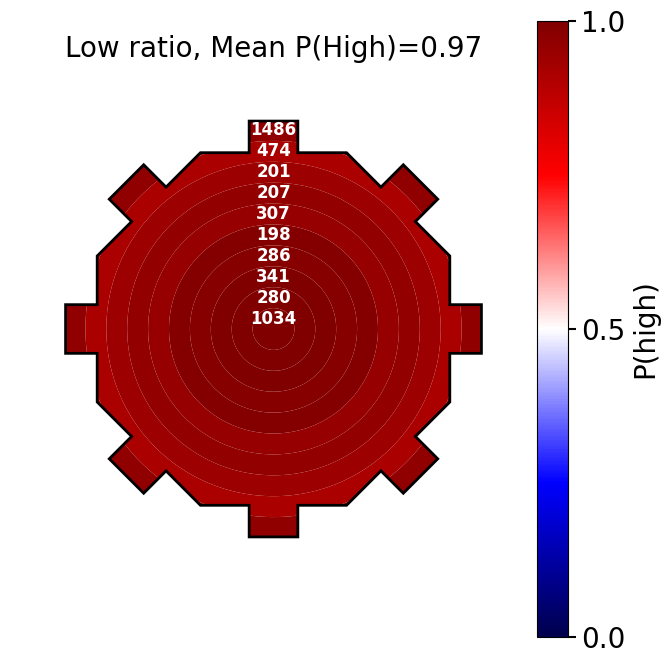

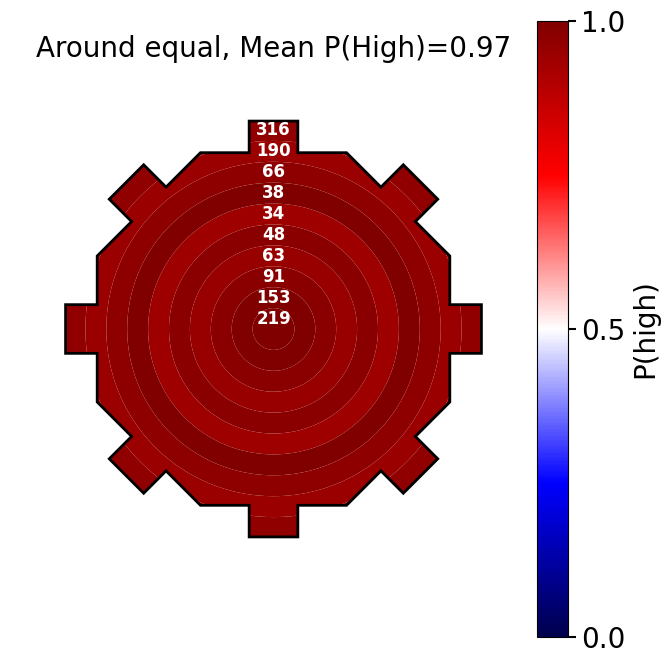

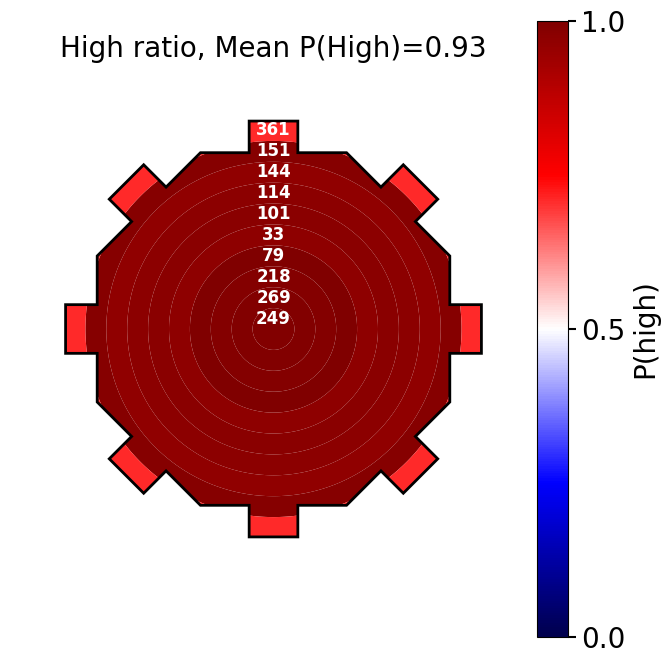

In [79]:
for i, group_name in enumerate(ratio_group_names):

    overall_p_high = (
    np.nansum(bins_wall_seen_wall_chosen_high[i]) /
    np.nansum(bins_wall_seen_high[i])
    )

    title = f"{group_name}, Mean P(High)={overall_p_high:.2f}"

    plot_heatmap_phigh_circular(
        probabilities_high[i],
        radial_bins,
        bin_counts=bins_wall_seen_high[i],
        cmap_name='seismic',
        diff_cmap_name='PiYG',
        title=title
    )

### Low first visible

In [39]:
first_visible_wall_index = 1
chosen_wall_index = 0

In [40]:
(trial_list_low_vis_filtered_low,
 trial_list_low_vis_and_choice_filtered_low) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    low_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_low_vis_filtered_equal,
 trial_list_low_vis_and_choice_filtered_equal) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    equal_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_low_vis_filtered_high,
 trial_list_low_vis_and_choice_filtered_high) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    high_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.
 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0.
 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1.
 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0.
 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1.
 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 

In [41]:
slice_onset_positions_low = {}
slice_onset_positions_equal = {}
slice_onset_positions_high = {}

ratio_group_lists = [
    low_ratio_lists,
    equal_ratio_lists,
    high_ratio_lists
]

slice_onset_position_dicts = [
    slice_onset_positions_low,
    slice_onset_positions_equal,
    slice_onset_positions_high
]

for group_lists, output_dict in zip(ratio_group_lists, slice_onset_position_dicts):
    for j, trial_list in enumerate(group_lists):
        pos_list = []

        for i in range(1, len(trial_list)):
            slice_onset_positions = opponent_visibility.get_player_position_slice_onset(
                player_id=0,
                trial=None,
                trial_list=trial_list,
                trial_index=i
            )
            pos_list.append(slice_onset_positions)

        output_dict[j] = pos_list

In [72]:
ratio_filtered = [
    trial_list_low_vis_filtered_low,
    trial_list_low_vis_filtered_equal,
    trial_list_low_vis_filtered_high
]

ratio_filtered_and_choice = [
    trial_list_low_vis_and_choice_filtered_low,
    trial_list_low_vis_and_choice_filtered_equal,
    trial_list_low_vis_and_choice_filtered_high
]

ratio_group_names = [
    "Low ratio",
    "Around equal",
    "High ratio"
]

In [73]:
all_positions = np.array([
    pos for pos_dict in [
        slice_onset_positions_low,
        slice_onset_positions_equal,
        slice_onset_positions_high
    ]
    for pos_list in pos_dict.values()
    for pos in pos_list
    if pos is not None
])

arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

num_radial_bins = 10
r_max = arena_radius
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

bins_wall_seen_low = []
bins_wall_seen_wall_chosen_low = []

for group_index, (group_name, filtered, filtered_and_choice) in enumerate(
    zip(ratio_group_names, ratio_filtered, ratio_filtered_and_choice),
    start=1
):
    wall_seen_counts = np.zeros(num_radial_bins)
    wall_seen_wall_chosen_counts = np.zeros(num_radial_bins)

    for player_id in range(num_players):

        trial_lists_denominator = filtered[player_id]
        trial_lists_numerator = filtered_and_choice[player_id]

        for trial_list in trial_lists_denominator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_counts[bin_index] += 1

        for trial_list in trial_lists_numerator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                r = np.sqrt(x_val**2 + y_val**2)
                bin_index = np.digitize(r, radial_bins) - 1

                if 0 <= bin_index < num_radial_bins:
                    wall_seen_wall_chosen_counts[bin_index] += 1

        print(
            f"Done for {group_name}, player {player_id}, "
            f"counts in numerator bin 0: {wall_seen_wall_chosen_counts[0]}"
        )

    bins_wall_seen_low.append(wall_seen_counts)
    bins_wall_seen_wall_chosen_low.append(wall_seen_wall_chosen_counts)

Done for Low ratio, player 0, counts in numerator bin 0: 676.0
Done for Around equal, player 0, counts in numerator bin 0: 231.0
Done for High ratio, player 0, counts in numerator bin 0: 223.0


In [74]:
pH_by_bin_low = []
probabilities_low = []

min_trials_per_bin = 15

for group_index, (group_name, numerator_counts, denominator_counts) in enumerate(
    zip(ratio_group_names, bins_wall_seen_wall_chosen_low, bins_wall_seen_low),
    start=1
):
    pH_by_bin = np.divide(
        numerator_counts,
        denominator_counts,
        out=np.zeros_like(numerator_counts, dtype=float),
        where=denominator_counts > 0
    )

    pH_by_bin[denominator_counts <= min_trials_per_bin] = np.nan

    pH_by_bin_low.append(pH_by_bin)
    probabilities_low.append(pH_by_bin)

    print(f"Computed probabilities for {group_name}")

Computed probabilities for Low ratio
Computed probabilities for Around equal
Computed probabilities for High ratio


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/1206041154.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


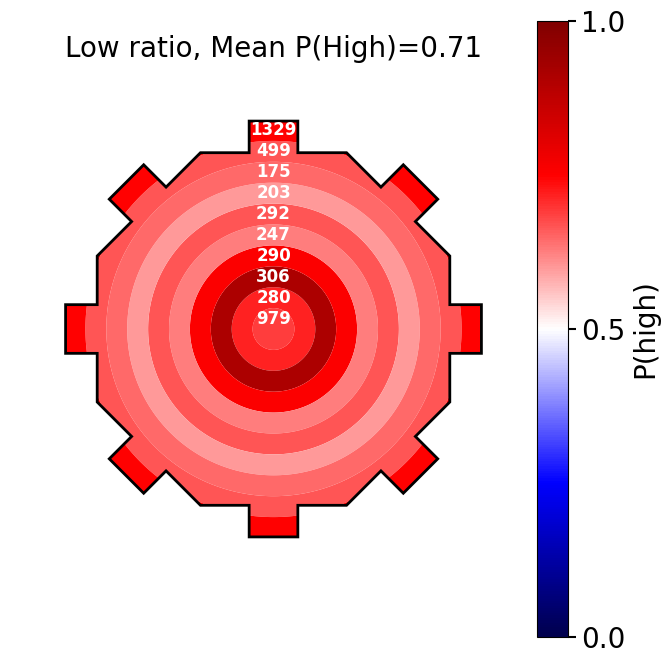

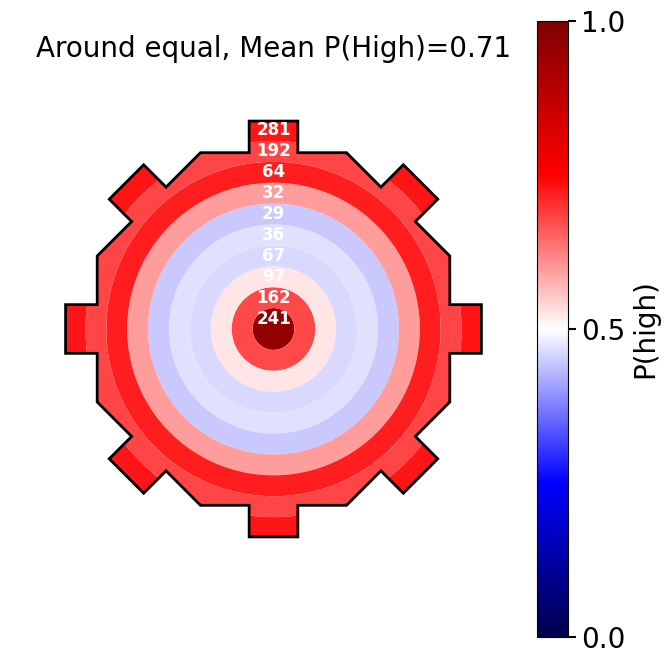

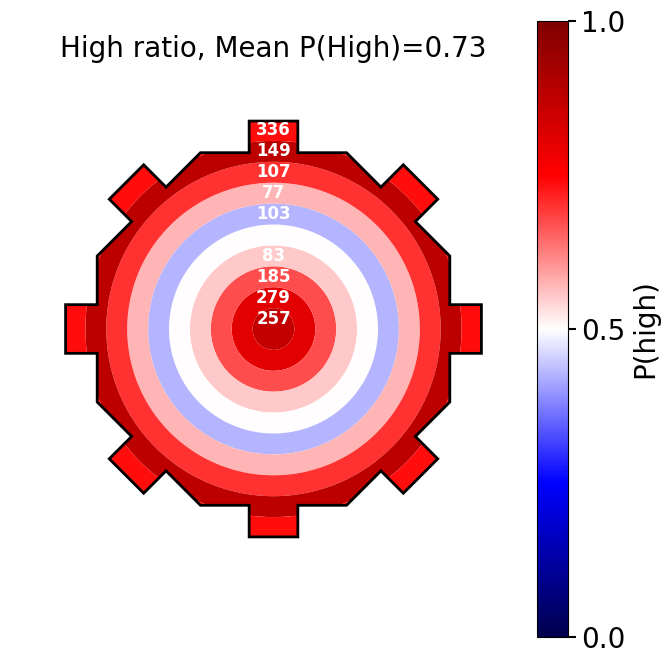

In [75]:
for i, group_name in enumerate(ratio_group_names):

    overall_p_high = (
    np.nansum(bins_wall_seen_wall_chosen_low[i]) /
    np.nansum(bins_wall_seen_low[i])
    )
    title = f"{group_name}, Mean P(High)={overall_p_high:.2f}"

    plot_heatmap_phigh_circular(
        probabilities_low[i],
        radial_bins,
        bin_counts=bins_wall_seen_low[i],
        cmap_name='seismic',
        diff_cmap_name='PiYG',
        title=title
    )

## Difference plots

In [80]:
probabilities_diff = []
for i in range(len(probabilities_high)):
    diff = probabilities_high[i] - probabilities_low[i]
    probabilities_diff.append(diff)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/1206041154.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


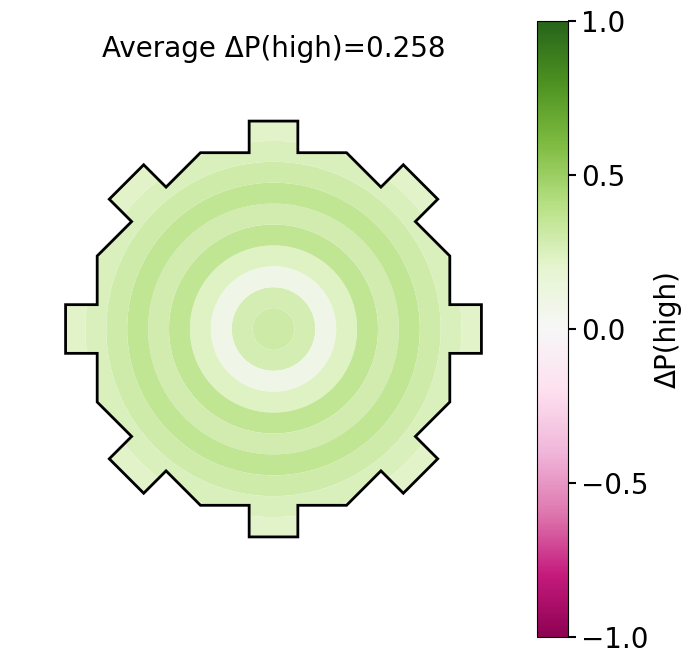

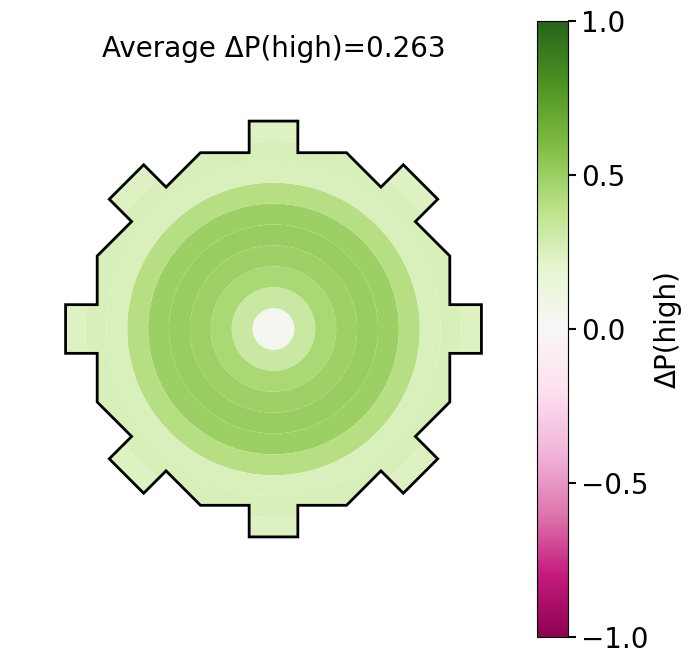

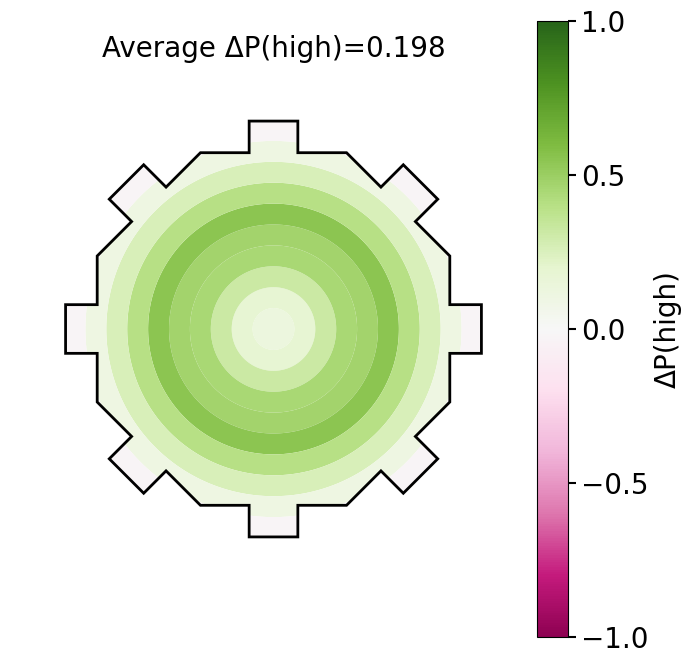

In [82]:
for i in range(len(probabilities_diff)):

    overall_p_high = (
        np.nansum(bins_wall_seen_wall_chosen_high[i]) /
        np.nansum(bins_wall_seen_high[i])
    )

    overall_p_low = (
        np.nansum(bins_wall_seen_wall_chosen_low[i]) /
        np.nansum(bins_wall_seen_low[i])
    )

    overall_diff = overall_p_high - overall_p_low
    plot_heatmap_phigh_circular(probabilities_diff[i], radial_bins, 
                                 cmap_name='PiYG', diff_cmap_name='PiYG', title= f"Average ΔP(high)={np.round(overall_diff,3)}", diff=True)

### Grid version

In [108]:
def compute_phigh_square_bins(
    filtered,
    filtered_and_choice,
    num_players=1,
    num_bins=10,
    arena_lim=25,
    min_trials_per_bin=15
):
    x_edges = np.linspace(-arena_lim, arena_lim, num_bins + 1)
    y_edges = np.linspace(-arena_lim, arena_lim, num_bins + 1)

    wall_seen_counts = np.zeros((num_bins, num_bins))
    wall_seen_wall_chosen_counts = np.zeros((num_bins, num_bins))

    for player_id in range(num_players):

        trial_lists_denominator = filtered[player_id]
        trial_lists_numerator = filtered_and_choice[player_id]

        # denominator
        for trial_list in trial_lists_denominator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                x_bin = np.digitize(x_val, x_edges) - 1
                y_bin = np.digitize(y_val, y_edges) - 1

                if 0 <= x_bin < num_bins and 0 <= y_bin < num_bins:
                    wall_seen_counts[y_bin, x_bin] += 1

        # numerator
        for trial_list in trial_lists_numerator:
            for trial in trial_list:
                x_val, y_val = get_indices.get_player_slice_onset_loc(
                    trial,
                    player_id=player_id
                )

                x_bin = np.digitize(x_val, x_edges) - 1
                y_bin = np.digitize(y_val, y_edges) - 1

                if 0 <= x_bin < num_bins and 0 <= y_bin < num_bins:
                    wall_seen_wall_chosen_counts[y_bin, x_bin] += 1

    p_high_grid = np.divide(
        wall_seen_wall_chosen_counts,
        wall_seen_counts,
        out=np.full_like(wall_seen_counts, np.nan, dtype=float),
        where=wall_seen_counts > 0
    )

    p_high_grid[wall_seen_counts <= min_trials_per_bin] = np.nan

    return p_high_grid, wall_seen_counts, wall_seen_wall_chosen_counts, x_edges, y_edges

In [110]:
def plot_heatmap_phigh_square(
    probabilities,
    x_edges,
    y_edges,
    bin_counts=None,
    cmap_name="seismic",
    title=None,
    diff=False,
    show_counts=True
):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name).copy()
    cmap.set_bad(color="white")

    if diff:
        norm = mpl.colors.Normalize(vmin=-1, vmax=1)
        cbar_label = "ΔP(high)"
    else:
        norm = mpl.colors.Normalize(vmin=0, vmax=1)
        cbar_label = "P(high)"

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        probabilities,
        cmap=cmap,
        norm=norm,
        shading="flat",
#        edgecolors="black",
        linewidth=0.3
    )

    # Clip the square grid to the octagon
    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor="none",
        edgecolor="none",
        transform=ax.transData
    )
    mesh.set_clip_path(octagon_clip)

    # Overlay octagon outline
    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor="black",
        facecolor="none",
        lw=2
    )
    ax.add_patch(octagon_patch)

    # Optional count labels
    if show_counts and bin_counts is not None:
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2

        for iy, y in enumerate(y_centers):
            for ix, x in enumerate(x_centers):
                if not np.isnan(probabilities[iy, ix]):
                    ax.text(
                        x,
                        y,
                        f"{int(bin_counts[iy, ix])}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="white",
                        fontweight="bold"
                    )

    if title is not None:
        ax.set_title(title, fontsize=20)

    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = plt.colorbar(mesh, ax=ax, pad=0, shrink=1)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    cbar.set_label(cbar_label, size=20)

    if diff:
        cbar.set_ticks(np.arange(-1, 1.1, 0.5))
    else:
        cbar.set_ticks(np.arange(0, 1.1, 0.5))

    return fig, ax

### High first visible

In [111]:
ratio_filtered = [
    trial_list_high_vis_filtered_low,
    trial_list_high_vis_filtered_equal,
    trial_list_high_vis_filtered_high
]

ratio_filtered_and_choice = [
    trial_list_high_vis_and_choice_filtered_low,
    trial_list_high_vis_and_choice_filtered_equal,
    trial_list_high_vis_and_choice_filtered_high
]

ratio_group_names = [
    "Low ratio",
    "Around equal",
    "High ratio"
]

In [112]:
p_high_square_grids_high = []
square_seen_counts_high = []
square_chosen_counts_high = []

for group_name, filtered, filtered_and_choice in zip(
    ratio_group_names,
    ratio_filtered,
    ratio_filtered_and_choice
):
    p_grid, seen_counts, chosen_counts, x_edges, y_edges = compute_phigh_square_bins(
        filtered,
        filtered_and_choice,
        num_players=num_players,
        num_bins=10,
        arena_lim=25,
        min_trials_per_bin=15
    )

    p_high_square_grids_high.append(p_grid)
    square_seen_counts_high.append(seen_counts)
    square_chosen_counts_high.append(chosen_counts)

    overall_p_high = np.nansum(chosen_counts) / np.nansum(seen_counts)

    print(f"{group_name}: overall P(high) = {overall_p_high:.3f}")

Low ratio: overall P(high) = 0.973
Around equal: overall P(high) = 0.975
High ratio: overall P(high) = 0.928


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/3632507376.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name).copy()


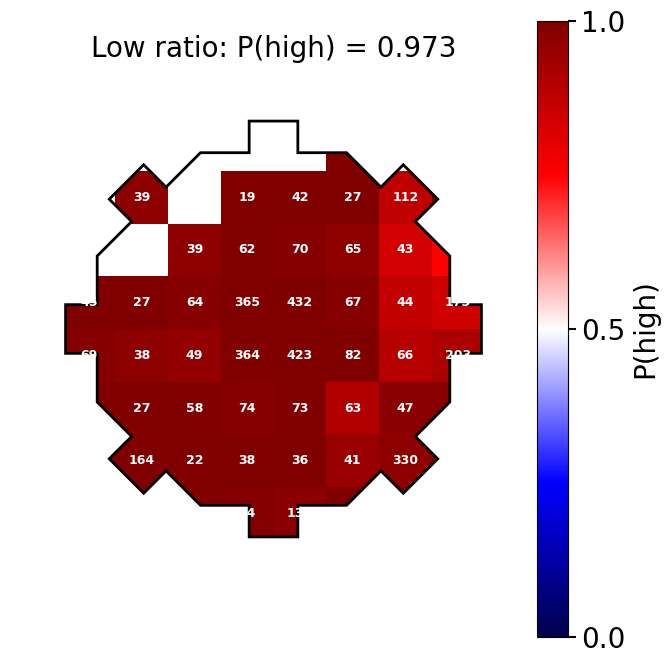

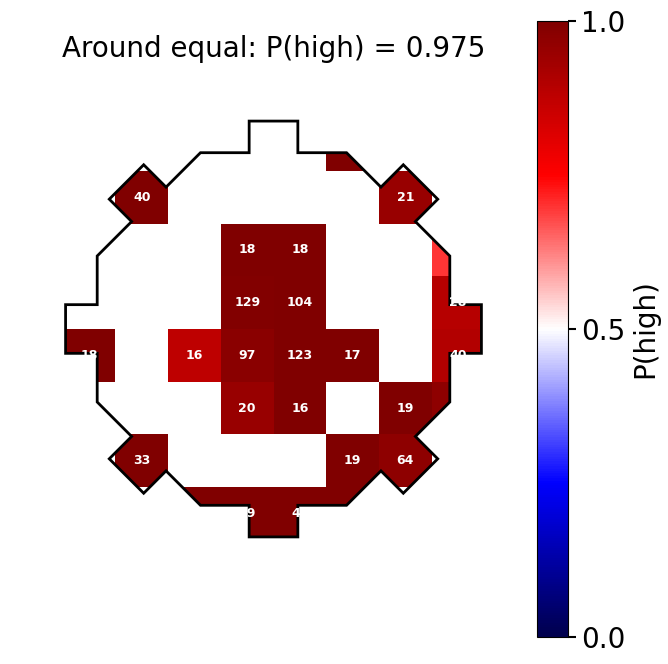

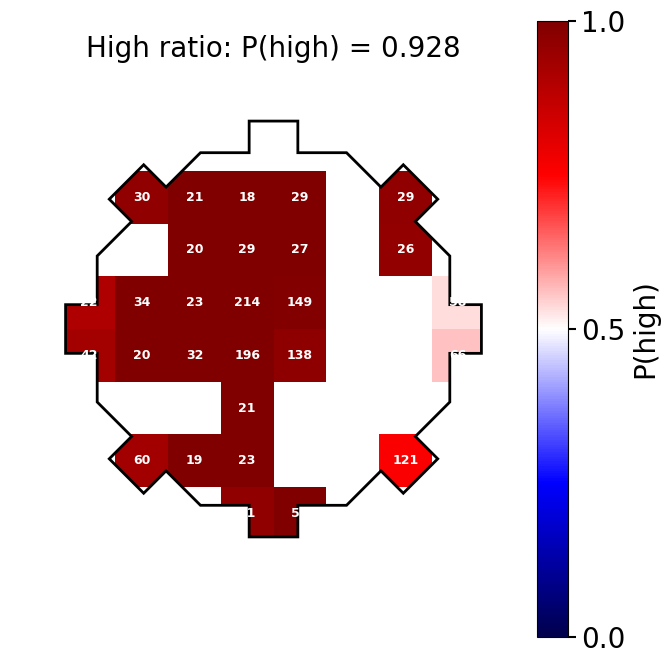

In [113]:
for i, group_name in enumerate(ratio_group_names):

    overall_p_high = (
        np.nansum(square_chosen_counts_high[i]) /
        np.nansum(square_seen_counts_high[i])
    )

    plot_heatmap_phigh_square(
        p_high_square_grids_high[i],
        x_edges,
        y_edges,
        bin_counts=square_seen_counts_high[i],
        cmap_name="seismic",
        title=f"{group_name}: P(high) = {overall_p_high:.3f}",
        diff=False,
        show_counts=True
    )

### Low first visible

In [114]:
ratio_filtered = [
    trial_list_low_vis_filtered_low,
    trial_list_low_vis_filtered_equal,
    trial_list_low_vis_filtered_high
]

ratio_filtered_and_choice = [
    trial_list_low_vis_and_choice_filtered_low,
    trial_list_low_vis_and_choice_filtered_equal,
    trial_list_low_vis_and_choice_filtered_high
]

ratio_group_names = [
    "Low ratio",
    "Around equal",
    "High ratio"
]

In [115]:
p_high_square_grids_low = []
square_seen_counts_low = []
square_chosen_counts_low = []

for group_name, filtered, filtered_and_choice in zip(
    ratio_group_names,
    ratio_filtered,
    ratio_filtered_and_choice
):
    p_grid, seen_counts, chosen_counts, x_edges, y_edges = compute_phigh_square_bins(
        filtered,
        filtered_and_choice,
        num_players=num_players,
        num_bins=10,
        arena_lim=25,
        min_trials_per_bin=15
    )

    p_high_square_grids_low.append(p_grid)
    square_seen_counts_low.append(seen_counts)
    square_chosen_counts_low.append(chosen_counts)

    overall_p_high = np.nansum(chosen_counts) / np.nansum(seen_counts)

    print(f"{group_name}: overall P(high) = {overall_p_high:.3f}")

Low ratio: overall P(high) = 0.714
Around equal: overall P(high) = 0.711
High ratio: overall P(high) = 0.730


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/3632507376.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name).copy()


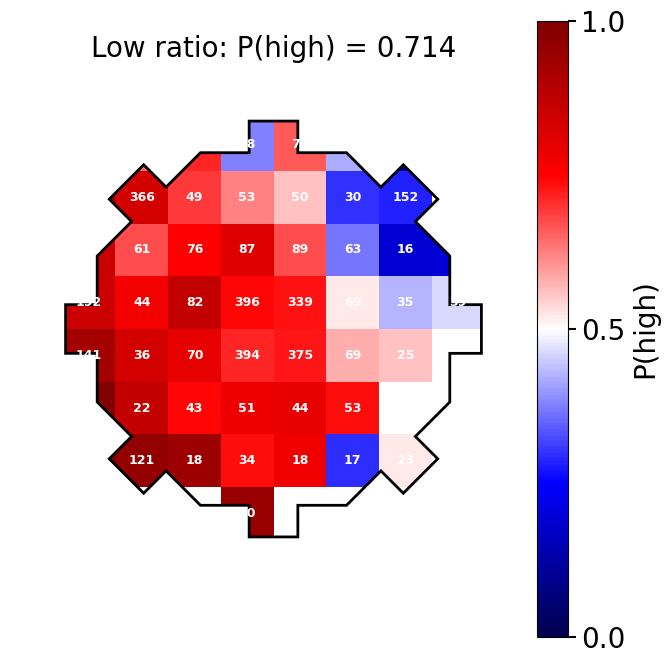

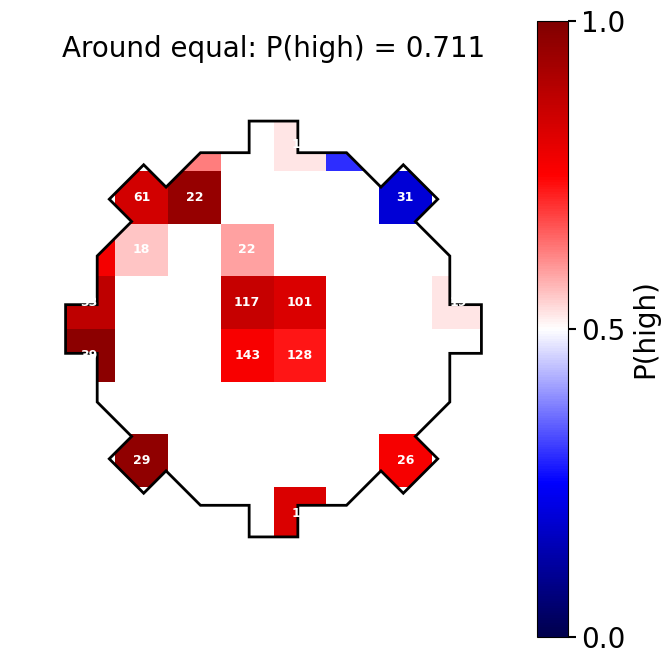

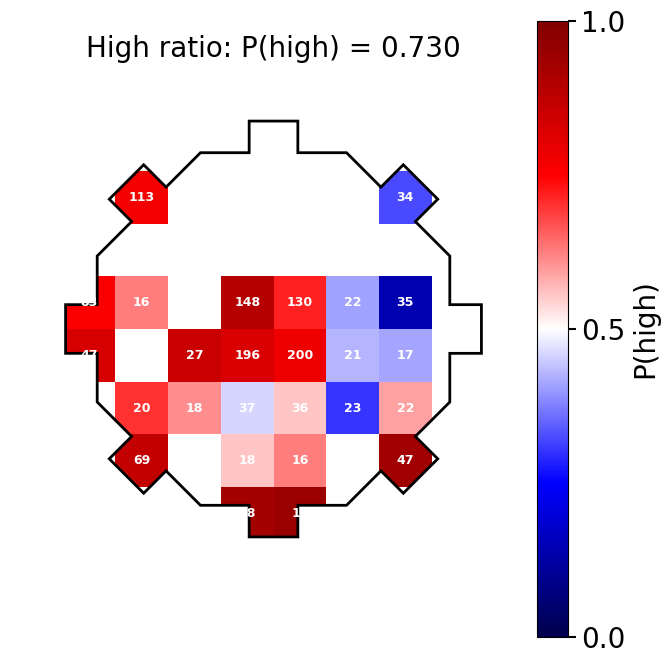

In [116]:
for i, group_name in enumerate(ratio_group_names):

    overall_p_high = (
        np.nansum(square_chosen_counts_low[i]) /
        np.nansum(square_seen_counts_low[i])
    )

    plot_heatmap_phigh_square(
        p_high_square_grids_low[i],
        x_edges,
        y_edges,
        bin_counts=square_seen_counts_low[i],
        cmap_name="seismic",
        title=f"{group_name}: P(high) = {overall_p_high:.3f}",
        diff=False,
        show_counts=True
    )

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_52651/3632507376.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name).copy()


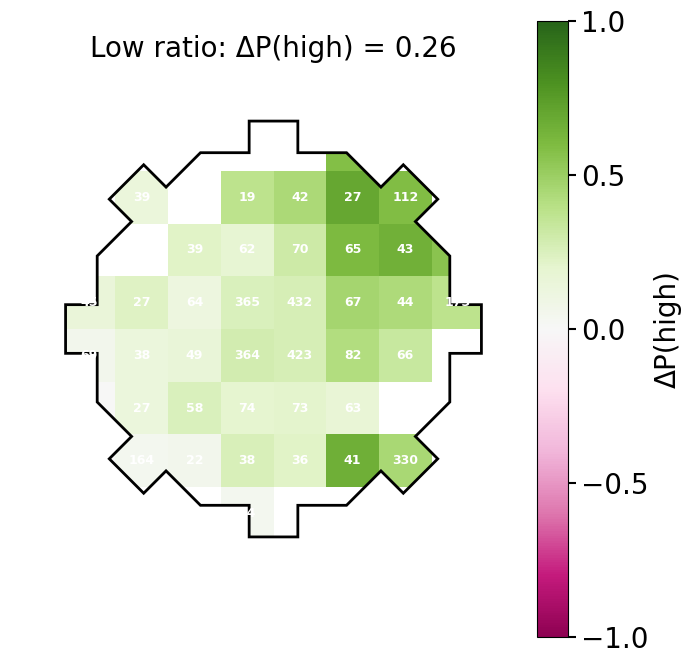

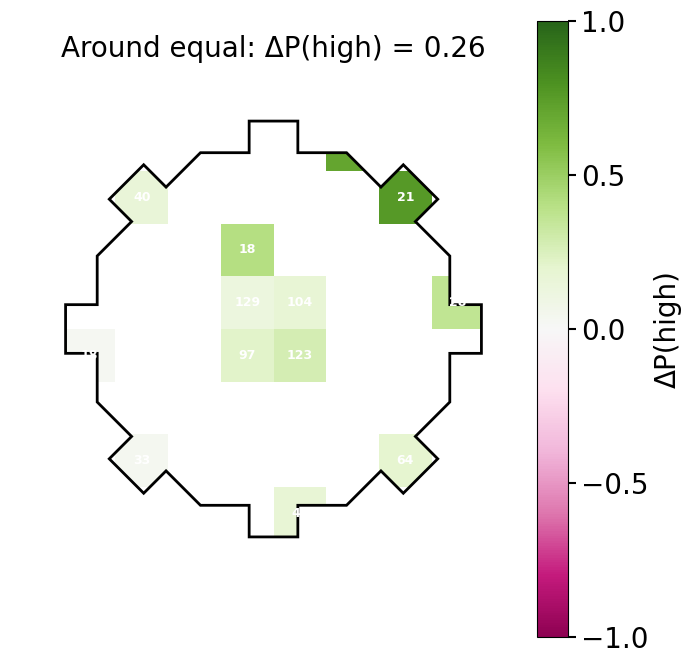

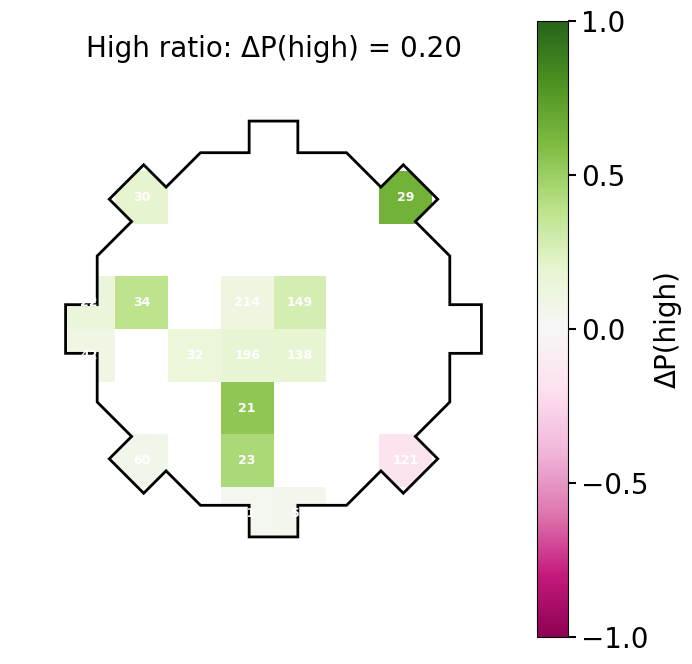

In [102]:
p_high_square_diff_grids = []

for i in range(len(p_high_square_grids_high)):
    diff_grid = p_high_square_grids_high[i] - p_high_square_grids_low[i]
    p_high_square_diff_grids.append(diff_grid)

    overall_p_high = (
        np.nansum(square_chosen_counts_high[i]) /
        np.nansum(square_seen_counts_high[i])
    )

    overall_p_low = (
        np.nansum(square_chosen_counts_low[i]) /
        np.nansum(square_seen_counts_low[i])
    )

    overall_diff = overall_p_high - overall_p_low

    plot_heatmap_phigh_square(
        diff_grid,
        x_edges,
        y_edges,
        bin_counts=square_seen_counts_high[i],
        cmap_name="PiYG",
        title=f"{ratio_group_names[i]}: ΔP(high) = {overall_diff:.2f}",
        diff=True,
        show_counts=True
    )

### P(Low | Low first seen)

In [24]:
# log_ratio < 0 : turning cost > translation cost
# log_ratio = 0 : equal costs
# log_ratio > 0 : translation cost > turning cost

num_players = 1
first_visible_wall_index = 1
chosen_wall_index = 1

thetas = np.asarray(thetas)

translation_costs = thetas[:, 0]
turning_costs = thetas[:, 1]

ratios = translation_costs / turning_costs
log_ratios = np.log2(ratios)

In [25]:
equal_window = 0.5  
# log2 ratio between -0.5 and 0.5 means within ~sqrt(2)-fold of equal costs

low_ratio_lists = []
equal_ratio_lists = []
high_ratio_lists = []

low_ratio_ids = []
equal_ratio_ids = []
high_ratio_ids = []

for session_id, (log_ratio, trial_list) in enumerate(zip(log_ratios, trial_lists)):

    if log_ratio < -equal_window:
        low_ratio_lists.append(trial_list)
        low_ratio_ids.append(session_id)

    elif log_ratio <= equal_window:
        equal_ratio_lists.append(trial_list)
        equal_ratio_ids.append(session_id)

    else:
        high_ratio_lists.append(trial_list)
        high_ratio_ids.append(session_id)

In [26]:
# all ratios

(trial_list_low_choice_high_vis_filtered,
 trial_list_low_choice_high_vis_and_choice_filtered) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    trial_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0.
 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1.
 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1.
 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0.
 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.
 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 

In [12]:
(trial_list_low_choice_high_vis_filtered_low,
 trial_list_low_choice_high_vis_and_choice_filtered_low) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    low_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_low_choice_high_vis_filtered_equal,
 trial_list_low_choice_high_vis_and_choice_filtered_equal) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    equal_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

(trial_list_low_choice_high_vis_filtered_high,
 trial_list_low_choice_high_vis_and_choice_filtered_high) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(
    high_ratio_lists,
    num_players,
    first_visible_wall_index,
    chosen_wall_index
)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1.
 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1.
 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 

In [17]:
for low_ratio_list in low_ratio_lists:
    print(f"Low ratio list length: {len(low_ratio_list)}")

Low ratio list length: 726
Low ratio list length: 223
Low ratio list length: 605
Low ratio list length: 599
Low ratio list length: 604
Low ratio list length: 596
Low ratio list length: 725
Low ratio list length: 720
Low ratio list length: 698
Low ratio list length: 528
Low ratio list length: 611
Low ratio list length: 640
Low ratio list length: 655
Low ratio list length: 702
Low ratio list length: 216
Low ratio list length: 657
Low ratio list length: 716
Low ratio list length: 0
Low ratio list length: 610
Low ratio list length: 314
Low ratio list length: 621
Low ratio list length: 669
Low ratio list length: 3
Low ratio list length: 3
Low ratio list length: 0
Low ratio list length: 692
Low ratio list length: 627


In [30]:
p_low_sessions = []

for session_id in range(len(trial_lists)):
    if len(trial_lists[session_id]) == 0:
        p_low = np.nan
    else:
        p_low = len(trial_list_low_choice_high_vis_and_choice_filtered[0][session_id]) / len(trial_lists[session_id])
    p_low_sessions.append(p_low)

In [21]:
p_low_1_lists = []
p_low_2_lists = []
p_low_3_lists = []


for session_id in range(len(low_ratio_lists)):
    if len(low_ratio_lists[session_id]) == 0:
        print(f"Session {session_id} has no complete trials.")
        p_low_1 = np.nan
        p_low_1_lists.append(p_low_1)
    else:
        p_low_1 = len(trial_list_low_choice_high_vis_and_choice_filtered_low[0][session_id]) / len(low_ratio_lists[session_id])
        p_low_1_lists.append(p_low_1)

for session_id in range(len(equal_ratio_lists)):
    if len(equal_ratio_lists[session_id]) == 0:
        print(f"Session {session_id} has no complete trials.")
        p_low_2 = np.nan
        p_low_2_lists.append(p_low_2)
    else:
        p_low_2 = len(trial_list_low_choice_high_vis_and_choice_filtered_equal[0][session_id]) / len(equal_ratio_lists[session_id])
        p_low_2_lists.append(p_low_2)

for session_id in range(len(high_ratio_lists)):
    if len(high_ratio_lists[session_id]) == 0:
        print(f"Session {session_id} has no complete trials.")
        p_low_3 = np.nan
        p_low_3_lists.append(p_low_3)
    else:
        p_low_3 = len(trial_list_low_choice_high_vis_and_choice_filtered_high[0][session_id]) / len(high_ratio_lists[session_id])
        p_low_3_lists.append(p_low_3)

Session 17 has no complete trials.
Session 24 has no complete trials.
Session 8 has no complete trials.


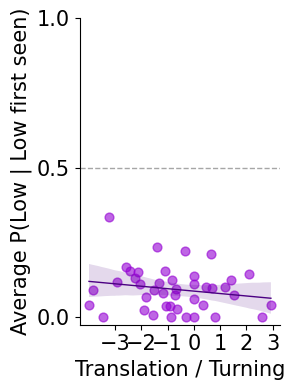

In [33]:
plt.figure(figsize=(3, 4))

sns.regplot(
    x=log_ratios,
    y=p_low_sessions,
    scatter_kws={"color": "darkviolet", "s": 40, "alpha": 0.6},
    line_kws={"color": "indigo", "linewidth": 1},
    ci=95,
)

plt.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)

plt.xticks(np.arange(-3, 3 + 0.1, 1), fontsize=15)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=15)

plt.xlabel("Translation / Turning", fontsize=15)
plt.ylabel("Average P(Low | Low first seen)", fontsize=15)

sns.despine()
plt.tight_layout()
plt.show()

### P(closest)